# Essai interface

In [1]:
import ipywidgets as widgets
import plotly.express as px
from ipywidgets import interact, widgets

In [2]:
import pandas as pd

df = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
# ventes totales par jour (global)
sales_per_day = df.iloc[:, 6:].sum(axis=0)
sales_per_day = sales_per_day.reset_index()
sales_per_day.columns = ["day", "sales"]

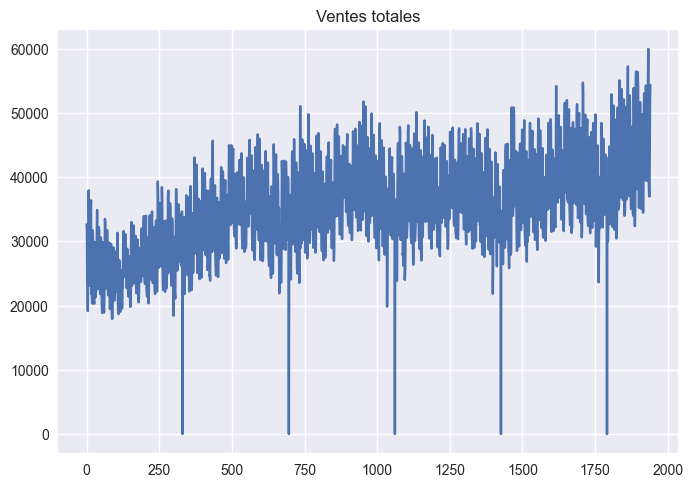

In [3]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.plot(sales_per_day["sales"])
plt.title("Ventes totales")
plt.show()

In [4]:
slider = widgets.IntSlider(
    value=100,          # valeur par défaut
    min=10,
    max=500,
    step=10,
    description="Nb jours"
)

display(slider)

IntSlider(value=100, description='Nb jours', max=500, min=10, step=10)

In [5]:
def afficher_ventes(nb_jours):
    # on sélectionne les X derniers jours
    data = sales_per_day.tail(nb_jours)
    
    plt.figure(figsize=(10,5))
    plt.plot(data["sales"])
    
    plt.title(f"Ventes sur les {nb_jours} derniers jours")
    plt.xlabel("Temps")
    plt.ylabel("Ventes")
    
    plt.show()

In [6]:
widgets.interact(afficher_ventes, nb_jours=slider)

interactive(children=(IntSlider(value=100, description='Nb jours', max=500, min=10, step=10), Output()), _dom_…

<function __main__.afficher_ventes(nb_jours)>

In [7]:
slider_smooth = widgets.IntSlider(
    value=7,
    min=1,
    max=30,
    step=1,
    description="Lissage"
)

In [8]:
def afficher_ventes(nb_jours, lissage):
    
    data = sales_per_day.tail(nb_jours).copy()
    
    # moyenne glissante
    data["smooth"] = data["sales"].rolling(lissage).mean()
    
    plt.figure(figsize=(10,5))
    
    plt.plot(data["sales"], label="Ventes réelles")
    plt.plot(data["smooth"], label="Tendance (lissée)")
    
    plt.title(f"Ventes sur {nb_jours} jours")
    plt.legend()
    
    plt.show()

In [9]:
widgets.interact(afficher_ventes, nb_jours=slider, lissage=slider_smooth)

interactive(children=(IntSlider(value=100, description='Nb jours', max=500, min=10, step=10), IntSlider(value=…

<function __main__.afficher_ventes(nb_jours, lissage)>

In [10]:
def afficher_ventes(nb_jours, lissage):
    
    data = sales_per_day.tail(nb_jours).copy()
    data["smooth"] = data["sales"].rolling(lissage).mean()
    
    print(f"Ventes moyennes : {int(data['sales'].mean())}")
    
    plt.figure(figsize=(10,5))
    plt.plot(data["sales"], label="Réel")
    plt.plot(data["smooth"], label="Tendance")
    plt.legend()
    plt.show()